## Spam classification with Navie Bayers

- libraries
- Exploring the Dataset
- Distribution spam and non-spam plots
- Text Analytics
- Feature Engineering 
- Predictive Analytics
- Predictive analysis (**Multinomial Naive Bayers and Gausian Naive Bayers**)
- conclusion

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import io
import os 
from collections import Counter
from IPython.display import Image
from sklearn import feature_extraction,model_selection,naive_bayes,metrics,svm

import warnings
warnings.filterwarnings('ignore')




### Exploring Dataset

In [3]:
df=pd.read_csv('../datasets/spam_ham_dataset.csv',encoding='latin1')
df

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0
...,...,...,...,...
5166,1518,ham,Subject: put the 10 on the ft\r\nthe transport...,0
5167,404,ham,Subject: 3 / 4 / 2000 and following noms\r\nhp...,0
5168,2933,ham,Subject: calpine daily gas nomination\r\n>\r\n...,0
5169,1409,ham,Subject: industrial worksheets for august 2000...,0


In [4]:
df.isnull().sum()

Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  5171 non-null   int64
 1   label       5171 non-null   str  
 2   text        5171 non-null   str  
 3   label_num   5171 non-null   int64
 4   clean_text  5171 non-null   str  
dtypes: int64(2), str(3)
memory usage: 8.6 MB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df= df.reset_index(drop=True)
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [8]:
df.drop('Unnamed: 0',axis=1)

,label,text,label_num
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,spam,"Subject: photoshop , windows , office . cheap ...",1
4,ham,Subject: re : indian springs\r\nthis deal is t...,0
...,...,...,...
5166,ham,Subject: put the 10 on the ft\r\nthe transport...,0
5167,ham,Subject: 3 / 4 / 2000 and following noms\r\nhp...,0
5168,ham,Subject: calpine daily gas nomination\r\n>\r\n...,0
5169,ham,Subject: industrial worksheets for august 2000...,0


In [9]:
df['label_num'].value_counts()

label_num
0    3672
1    1499
Name: count, dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

### Distribution of spam and non_spam plots


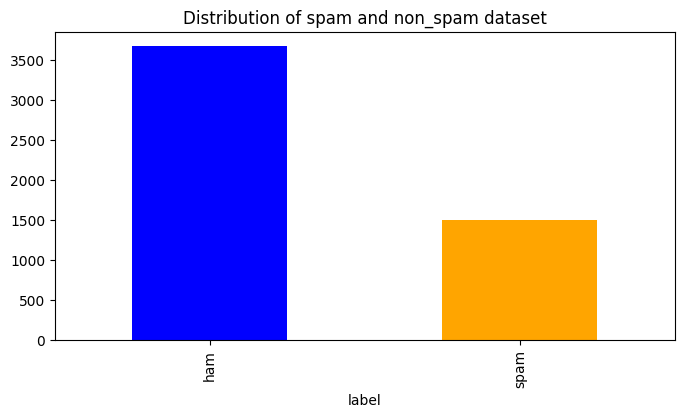

In [11]:

plt.figure(figsize=(8,4))

plt.title("Distribution of spam and non_spam dataset")

count=df.value_counts(df['label'])
count.plot(kind='bar',color=['blue','orange'])
plt.show()


### Text Analytics
- we wnat to find the frequencies of worlds in spam and non_spam message.The words of messages.The words of the message will be in model feature 
- we use the function counter 

In [12]:
count1=Counter(' '.join(df[df['label']=='ham']['text']).split()).most_common(20)
df1=pd.DataFrame.from_dict(count1)
df1=df1.rename(columns={0:'words in non-spam',1:'count_'})
count2=Counter(' '.join(df[df['label']=='spam']['text']).split()).most_common(20)
df2=pd.DataFrame.from_dict(count2)
df2=df2.rename(columns={0:'words in spam',1:'count_'})

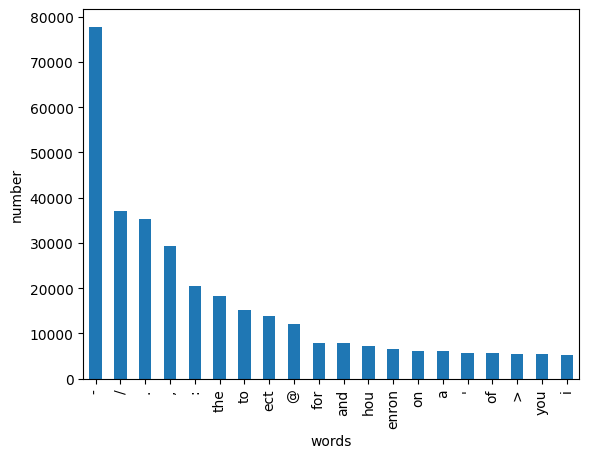

In [13]:
df1.plot.bar(legend=False)
y_pos=np.arange(len(df1['words in non-spam']))
plt.xticks(y_pos,df1['words in non-spam'])
plt.title('')
plt.xlabel('words')
plt.ylabel('number')
plt.show()

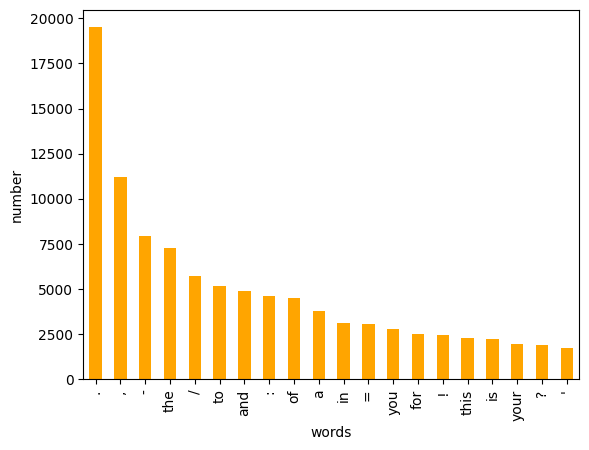

In [14]:
df2.plot.bar(legend=False,color='orange')
y_pos=np.arange(len(df2['words in spam']))
plt.xticks(y_pos,df2['words in spam'])
plt.xlabel('words')
plt.ylabel('number')
plt.show()

we can see that the majority of frequent word in both classes are stop such  as -,the ,@,of .


with stop words we refer to the most common words in a language, there in no single, universal list of stop words

In [15]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re


In [16]:
from nltk.tokenize import word_tokenize
nltk.download('punkt')



nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove punctuation & numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize using split
    words = word_tokenize(text)
    
    # Remove stopwords + Lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [17]:
count1=Counter(' '.join(df[df['label']=='ham']['clean_text']).split()).most_common(20)
df1=pd.DataFrame.from_dict(count1)
df1=df1.rename(columns={0:'words in non-spam',1:'count_'})
count2=Counter(' '.join(df[df['label']=='spam']['clean_text']).split()).most_common(20)
df2=pd.DataFrame.from_dict(count2)
df2=df2.rename(columns={0:'words in spam',1:'count_'})

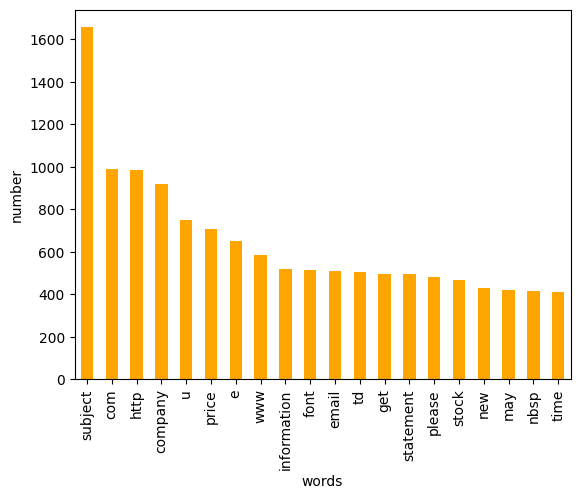

In [18]:
df2.plot.bar(legend=False,color='orange')
y_pos=np.arange(len(df2['words in spam']))
plt.xticks(y_pos,df2['words in spam'])
plt.xlabel('words')
plt.ylabel('number')
plt.show()

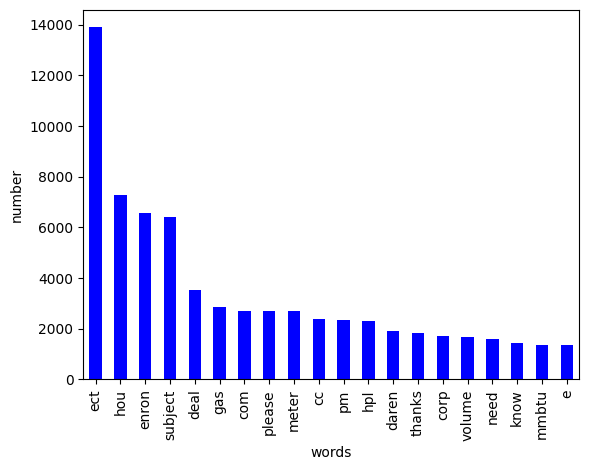

In [19]:
df1.plot.bar(legend=False,color='blue')
y_pos=np.arange(len(df1['words in non-spam']))
plt.xticks(y_pos,df1['words in non-spam'])
plt.xlabel('words')
plt.ylabel('number')
plt.show()

In [20]:
df

,Unnamed: 0,label,text,label_num,clean_text
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0,subject enron methanol meter follow note gave ...
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,subject hpl nom january see attached file hpln...
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,subject neon retreat ho ho ho around wonderful...
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1,subject photoshop window office cheap main tre...
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0,subject indian spring deal book teco pvr reven...
...,...,...,...,...,...
5166,1518,ham,Subject: put the 10 on the ft\r\nthe transport...,0,subject put ft transport volume decreased cont...
5167,404,ham,Subject: 3 / 4 / 2000 and following noms\r\nhp...,0,subject following noms hpl take extra mmcf wee...
5168,2933,ham,Subject: calpine daily gas nomination\r\n>\r\n...,0,subject calpine daily gas nomination julie men...
5169,1409,ham,Subject: industrial worksheets for august 2000...,0,subject industrial worksheet august activity a...


### Conclusion 
Initially, the word frequency analysis was dominated by stopwords and punctuation, which added noise to the dataset. After applying text preprocessing techniques such as lowercasing, punctuation removal, stopword removal, and lemmatization, the dataset became cleaner and more meaningful. The updated word distribution now reflects relevant terms, which improves the quality of text analysis. Therefore, text cleaning is a crucial step in Natural Language Processing to ensure accurate and reliable insights.

### Feature Engineering 


## We are doing feature embeding 

In [21]:
from sklearn import feature_extraction

x=feature_extraction.text.CountVectorizer()
x=x.fit_transform(df['clean_text']).toarray()
np.shape(x)



(5171, 43226)

- we have created more than 63395.The new feature 

In [22]:
x

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5171, 43226))

In [23]:
y=df['label_num']
y

0       0
1       0
2       0
3       1
4       0
       ..
5166    0
5167    0
5168    0
5169    0
5170    1
Name: label_num, Length: 5171, dtype: int64

In [24]:
from sklearn.model_selection import train_test_split


x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

print([np.shape(x_train),np.shape(x_test)])

[(3619, 43226), (1552, 43226)]


### Multinomial naive bayes classifier

we train different bayes models changing the regularization parameter alpha 

 we evaluate the accuracy ,recall and precision of the model with the set 
 

In [25]:
list_alpha=np.arange(1/100000,10,2)   ## start stop step 
score_train=np.zeros(len(list_alpha)) 
score_test=np.zeros(len(list_alpha))
recall_test=np.zeros(len(list_alpha))
precision_test=np.zeros(len(list_alpha)) 
count=0

for alpha in list_alpha:
    bayes=naive_bayes.MultinomialNB(alpha=alpha)
    bayes.fit(x_train,y_train)  
    score_train[count]=bayes.score(x_train,y_train)
    score_test[count]=bayes.score(x_test,y_test)
    recall_test[count]=metrics.recall_score(y_test,bayes.predict(x_test))
    precision_test[count]=metrics.precision_score(y_test,bayes.predict(x_test))
    count=count+1




In [26]:
matrix = np.matrix(np.c_[list_alpha, score_train, score_test, recall_test, precision_test])

models = pd.DataFrame(
    data=matrix,
    columns=['alpha', 'Train Accuracy', 'test_Accuracy', 'Test Recall', 'Test precision']
)

models

,alpha,Train Accuracy,test_Accuracy,Test Recall,Test precision
0,0.00001,0.993092,0.978737,0.967517,0.956422
1,2.00001,0.982868,0.972938,0.939675,0.961995
2,4.00001,0.975960,0.965206,0.904872,0.967742
3,6.00001,0.967947,0.956186,0.863109,0.976378
4,8.00001,0.962421,0.947809,0.825986,0.983425


In [27]:
best_index=models['Test precision'].idxmax()
models.iloc[best_index,:]

alpha             8.000010
Train Accuracy    0.962421
test_Accuracy     0.947809
Test Recall       0.825986
Test precision    0.983425
Name: 4, dtype: float64

In [28]:
models[models['Test precision']== models['Test precision'].max()].head(n=5)


,alpha,Train Accuracy,test_Accuracy,Test Recall,Test precision
4,8.00001,0.962421,0.947809,0.825986,0.983425


In [29]:
## confusion matirx

from sklearn.metrics import classification_report
m_confusion=metrics.confusion_matrix(y_test,bayes.predict(x_test))
m_confusion




array([[1115,    6],
       [  75,  356]])